<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

### **Course:** DSC550 — Data Mining
### **Name:** Tim Hollis
### **Assignment:** Exercise 5.2
### **Date:** 04/14/2026

---

Reference: Kaggle. (n.d.). *Word2Vec NLP tutorial: Labeled training data* [Dataset]. Retrieved from https://www.kaggle.com/competitions/word2vec-nlp-tutorial/data

</div>

### **Initial Setup:**

In [1]:
# Load Libraries
import matplotlib.pyplot as plt
import numpy as np
import nltk
import pandas as pd
import re
import seaborn as sns
import warnings

from IPython.display import display, HTML
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc
)
from sklearn.svm import LinearSVC

# Visual Formatting
display(HTML('''
<style>
div.output_subarea { page-break-inside: avoid; }
div.jp-MarkdownOutput { page-break-inside: avoid; }
div.cell { page-break-inside: avoid; }
</style>
'''))

# Suppress warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Load dataset
df = pd.read_csv('labeledTrainData.tsv', sep='\t')

print('Setup complete.')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
display(df.head())
print('\nSentiment counts:')
print(df['sentiment'].map({1: 'Positive', 0: 'Negative'}).value_counts())

Setup complete.
Shape: (25000, 3)

First 5 rows:


,id,sentiment,review
0,5814_8,1,"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just wa..."
1,2381_9,1,"\The Classic War of the Worlds\"" by Timothy Hines is a very entertaining film that obviously goes to great effort and lengths to faithfully recreate H. G. Wells' classic book. Mr. Hines succeeds i..."
2,7759_3,0,"The film starts with a manager (Nicholas Bell) giving welcome investors (Robert Carradine) to Primal Park . A secret project mutating a primal animal using fossilized DNA, like ¨Jurassik Park¨, an..."
3,3630_4,0,"It must be assumed that those who praised this film (\the greatest filmed opera ever,\"" didn't I read somewhere?) either don't care for opera, don't care for Wagner, or don't care about anything e..."
4,9495_8,1,"Superbly trashy and wondrously unpretentious 80's exploitation, hooray! The pre-credits opening sequences somewhat give the false impression that we're dealing with a serious and harrowing drama, ..."



Sentiment counts:
sentiment
Positive    12500
Negative    12500
Name: count, dtype: int64


### **Pre-Processing**

In [2]:
# Initialize Stopwords and Stemming
stop_words = set(stopwords.words('english'))
ps = PorterStemmer()


def preprocess_text(text):
    """Completes the below:
    - Convert text to lowercase
    - Remove punctuation and non-letter characters
    - Remove English stop words
    - Apply Porter stemming to reduce words to their root forms"""

    # Lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove stop words
    words = [word for word in text.split() if word not in stop_words]

    # Stemming
    stemmed = [ps.stem(word) for word in words]

    return ' '.join(stemmed)


# Apply preprocessing
df['clean_review'] = df['review'].apply(preprocess_text)

print('Preprocessing complete.')
display(df[['review', 'clean_review']].head())

Preprocessing complete.


,review,clean_review
0,"With all this stuff going down at the moment with MJ i've started listening to his music, watching the odd documentary here and there, watched The Wiz and watched Moonwalker again. Maybe i just wa...",stuff go moment mj ive start listen music watch odd documentari watch wiz watch moonwalk mayb want get certain insight guy thought realli cool eighti mayb make mind whether guilti innoc moonwalk p...
1,"\The Classic War of the Worlds\"" by Timothy Hines is a very entertaining film that obviously goes to great effort and lengths to faithfully recreate H. G. Wells' classic book. Mr. Hines succeeds i...",classic war world timothi hine entertain film obvious goe great effort length faith recreat h g well classic book mr hine succe watch film appreci fact standard predict hollywood fare come everi y...
2,"The film starts with a manager (Nicholas Bell) giving welcome investors (Robert Carradine) to Primal Park . A secret project mutating a primal animal using fossilized DNA, like ¨Jurassik Park¨, an...",film start manag nichola bell give welcom investor robert carradin primal park secret project mutat primal anim use fossil dna like jurassik park scientist resurrect one natur fearsom predat sabre...
3,"It must be assumed that those who praised this film (\the greatest filmed opera ever,\"" didn't I read somewhere?) either don't care for opera, don't care for Wagner, or don't care about anything e...",must assum prais film greatest film opera ever didnt read somewher either dont care opera dont care wagner dont care anyth except desir appear cultur either represent wagner swansong movi strike u...
4,"Superbly trashy and wondrously unpretentious 80's exploitation, hooray! The pre-credits opening sequences somewhat give the false impression that we're dealing with a serious and harrowing drama, ...",superbl trashi wondrous unpretenti exploit hooray precredit open sequenc somewhat give fals impress deal seriou harrow drama need fear bare ten minut later neck nonsens chainsaw battl rough fistfi...


### **Train/Test Split + TF-IDF Vectorization**

The TF-IDF vectorizer is fit on training data only and applied (not re-fit) to the test set. Fitting on the test set would allow vocabulary and term weights to reflect test data the model has never "seen," introducing data leakage and artificially inflating performance estimates.

In [3]:
# Split data
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer()

# Fit on training data ONLY
X_train_tfidf = tfidf.fit_transform(X_train)

# Transform test data (no fitting)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF vectorization complete.')
print('Training matrix shape:', X_train_tfidf.shape)
print('Test matrix shape:', X_test_tfidf.shape)

TF-IDF vectorization complete.
Training matrix shape: (20000, 78613)
Test matrix shape: (5000, 78613)


### **Logistic Regression Model**

In [4]:
# Initialize model
log_reg = LogisticRegression(max_iter=1000)

# Train model
log_reg.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred_lr = log_reg.predict(X_test_tfidf)

# Accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print('Logistic Regression training complete.')
print(f'Accuracy: {lr_accuracy:.4f}')

Logistic Regression training complete.
Accuracy: 0.8850


### **Confusion Matrix for Logistic Regression**

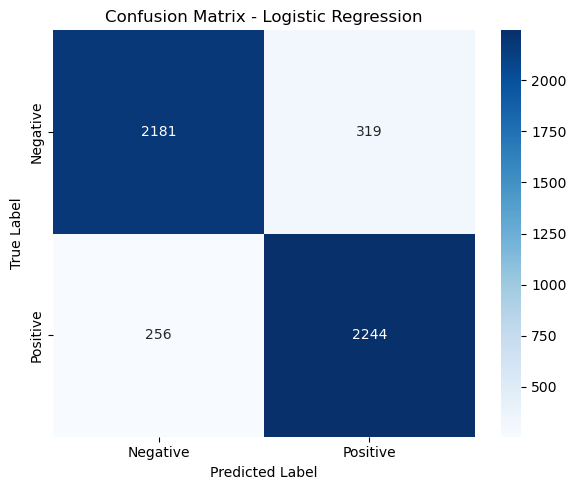

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Precision, Recall, and F1-Score for Logistic Regression**

In [6]:
# Precision for logistic regression
lr_precision = precision_score(y_test, y_pred_lr)

# Recall for logistic regression
lr_recall = recall_score(y_test, y_pred_lr)

# F1 for logistic regression
lr_f1 = f1_score(y_test, y_pred_lr)

print(f'Precision: {lr_precision:.4f}')
print(f'Recall:    {lr_recall:.4f}')
print(f'F1-Score:  {lr_f1:.4f}')

Precision: 0.8755
Recall:    0.8976
F1-Score:  0.8864


### **ROC Curve for Logistic Regression**

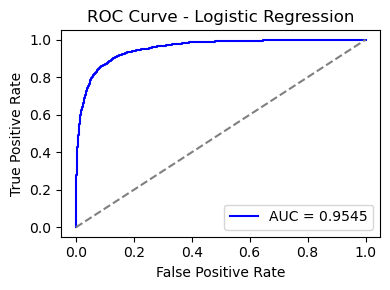

ROC AUC: 0.9545


In [7]:
# Get predicted probabilities for the positive class
y_prob_lr = log_reg.predict_proba(X_test_tfidf)[:, 1]

# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(4, 3))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('ROC Curve - Logistic Regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'ROC AUC: {roc_auc:.4f}')

<div style="page-break-after: always;"></div>

### **Support Vector Machine (LinearSVC) Model**

In [8]:
# Initialize model
svm_model = LinearSVC()

# Train model
svm_model.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred_svm = svm_model.predict(X_test_tfidf)

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print('Support Vector Machine training complete.')
print(f'Accuracy: {svm_accuracy:.4f}')

Support Vector Machine training complete.
Accuracy: 0.8870


### **Confusion Matrix for Support Vector Machine**

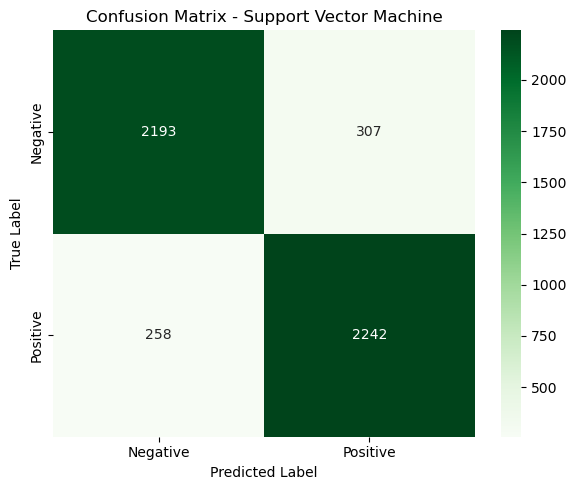

In [9]:
# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.title('Confusion Matrix - Support Vector Machine')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

### **Precision, Recall, and F1-Score for Support Vector Machine**

In [10]:
# Precision for SVM
svm_precision = precision_score(y_test, y_pred_svm)

# Recall for SVM
svm_recall = recall_score(y_test, y_pred_svm)

# F1 for SVM
svm_f1 = f1_score(y_test, y_pred_svm)

print(f'Precision: {svm_precision:.4f}')
print(f'Recall:    {svm_recall:.4f}')
print(f'F1-Score:  {svm_f1:.4f}')

Precision: 0.8796
Recall:    0.8968
F1-Score:  0.8881


### **ROC Curve for Support Vector Machine**

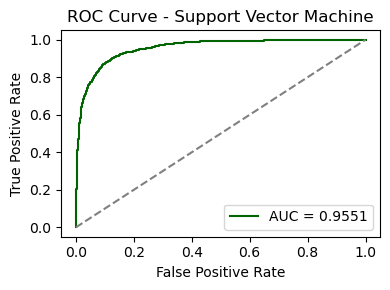

ROC AUC: 0.9551


In [11]:
# Get decision scores
y_scores_svm = svm_model.decision_function(X_test_tfidf)

# Compute ROC curve values
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_scores_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

# Plot ROC curve
plt.figure(figsize=(4, 3))
plt.plot(fpr_svm, tpr_svm, color='darkgreen', label=f'AUC = {roc_auc_svm:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')

plt.title('ROC Curve - Support Vector Machine')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f'ROC AUC: {roc_auc_svm:.4f}')

<div style="border: 5px solid black; border-radius: 8px; padding: 20px;">

## Model Performance Summary

Both Logistic Regression and Support Vector Machine models performed strongly on the IMDB sentiment classification task. Logistic Regression achieved an accuracy of **0.8850** with an F1‑score of **0.8864**, while the SVM model slightly outperformed it with an accuracy of **0.8870** and an F1‑score of **0.8881**. The ROC AUC values were similarly high for both models (**0.9545** for Logistic Regression and **0.9551** for SVM), indicating excellent separation between positive and negative reviews.

The confusion matrices show that SVM produced fewer false positives (307 vs. 319), which contributed to its higher precision (**0.8796** compared to **0.8755** for Logistic Regression). Logistic Regression produced slightly fewer false negatives (256 vs. 258), resulting in a marginally higher recall (**0.8976** vs. **0.8968**). These differences are small but consistent, and they reflect the typical behavior of each model: Logistic Regression tends to be slightly more recall‑oriented, while SVM tends to reduce false positives.

Overall, the SVM model provided the best performance across most metrics. This outcome aligns with expectations for high‑dimensional TF‑IDF text data, where linear SVMs often excel due to their ability to maximize class separation in sparse feature spaces.

</div>

<div style="border: 5px solid green; border-radius: 8px; padding: 20px;">

# Reflection

This week’s assignment brought together several core concepts from the course and allowed me to build a complete text‑classification pipeline using the IMDB movie reviews dataset. Revisiting the same dataset from Week 3 helped reinforce how preprocessing, vectorization, and model selection all connect in a practical workflow. Seeing the entire process—from stemming to TF‑IDF to model evaluation—laid out in one notebook made the structure of text mining feel much more cohesive and intuitive.

## What Felt Straightforward

Many parts of the assignment felt familiar because they built directly on earlier exercises. Preprocessing the text using lowercasing, stop‑word removal, and Porter stemming followed the same workflow from Week 3, so that portion moved smoothly. Splitting the data into training and test sets and fitting TF‑IDF **only on the training set** was also clear, especially with the emphasis on avoiding data leakage. Training the Logistic Regression model and generating accuracy, precision, recall, F1‑score, confusion matrices, and ROC curves felt natural since these metrics have been used consistently throughout the course. Repeating the same steps for the LinearSVC model made the comparison straightforward and reinforced the value of evaluating multiple algorithms on the same feature space.

## What Was More Challenging

The more challenging aspect was interpreting the subtle differences between the two models and explaining why they occurred. Both models performed extremely well, with accuracy and F1‑scores differing only slightly, so explaining the practical meaning of those differences required more nuance. Another challenge was thinking beyond the results and reflecting on the modeling choices—why Logistic Regression and LinearSVC are well‑suited for high‑dimensional TF‑IDF data, and how their underlying mechanics influence precision, recall, and AUC. This connects directly to my feedback from our professor, to briefly justify key model choices rather than only report outcomes, and his suggestion to include a summary comparison table highlighted the importance of presenting results in a consolidated format that makes patterns immediately visible. While I compared the models narratively, a table would have made the comparison clearer and more professional. This is something I will incorporate into future assignments.

## Overall Reflection

Overall, this assignment strengthened my understanding of how text data moves through a predictive modeling pipeline and how different algorithms behave when applied to sparse, high‑dimensional features. It also reinforced the importance of thoughtful evaluation—looking beyond accuracy to metrics like precision, recall, and AUC, and understanding how each one reflects different trade‑offs in model behavior. The instructor’s feedback was especially helpful in reminding me to justify modeling decisions and to present results in a more consolidated, comparative format. Moving forward, I plan to incorporate summary tables and brief methodological justifications as standard practice, since they make the analysis clearer, more transparent, and easier to interpret.

</div>